In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Keys in npz file: ['stream_0_Neurodaq']
Loaded shape for 'stream_0_Neurodaq': (5500, 8)


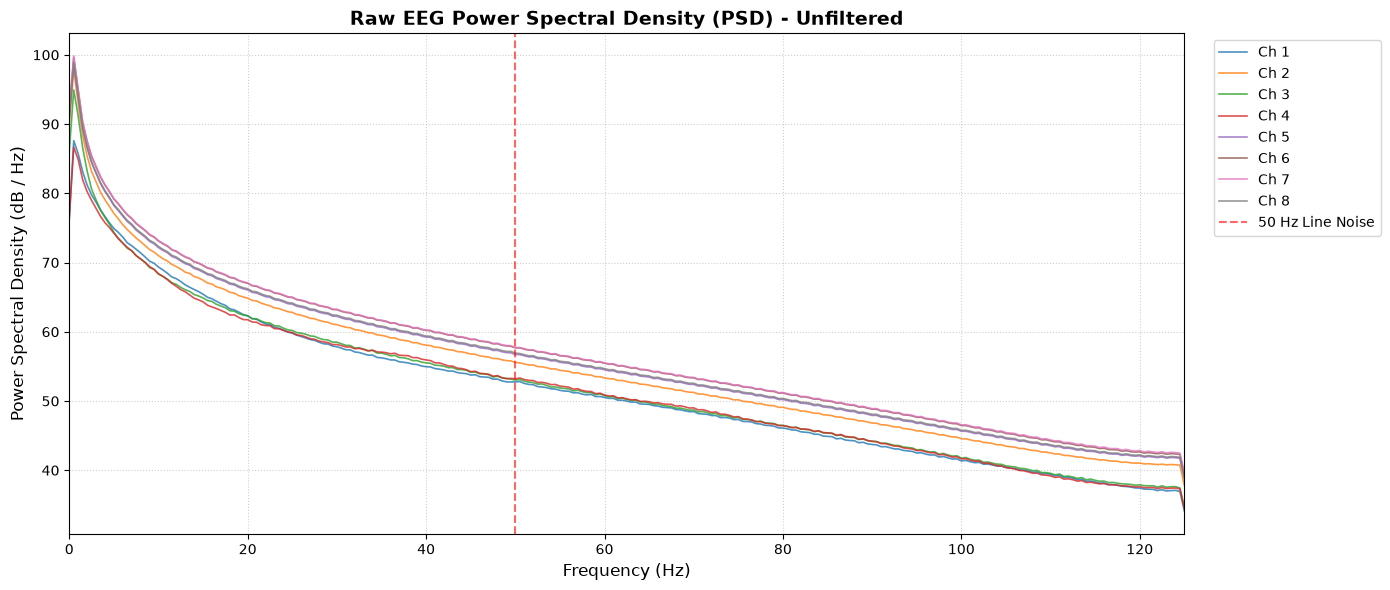

In [4]:


# --- 1. Load the Recorded Raw Data ---
# Update with your recorded filename
file_path = "recordings/open.npz"
data = np.load(file_path)

# View saved keys in the archive
print("Keys in npz file:", list(data.keys()))

# Extract data array (Assuming the first stream key)
stream_key = list(data.keys())[0]
raw_data = data[stream_key]  # Expected shape: (Samples, Channels)

print(f"Loaded shape for '{stream_key}': {raw_data.shape}")

# --- 2. Parameters ---
# Sampling Rate in Hz (Adjust if different, e.g., 250 Hz for ADS1299/OpenBCI)
FS = 250.0
# 2-second windows for high-resolution low-frequency bins (~0.5 Hz resolution)
NPERSEG = int(FS * 2)

# --- 3. Compute PSD using Welch's Method ---
# returns frequencies (freqs) and power spectral density (psd)
freqs, psd = signal.welch(raw_data, fs=FS, nperseg=NPERSEG, axis=0)

# Convert PSD to decibels (dB) for better visualization of tiny HF interference & large DC/line spikes
psd_db = 10 * np.log10(psd + 1e-12)

# --- 4. Plot the Frequency Spectrum ---
plt.figure(figsize=(14, 6), dpi=100)

num_channels = raw_data.shape[1]
for ch in range(num_channels):
    plt.plot(freqs, psd_db[:, ch],
             label=f"Ch {ch + 1}", alpha=0.8, linewidth=1.2)

# Highlighting Common Debug Frequencies
plt.axvline(x=50, color='red', linestyle='--',
            alpha=0.6, label='50 Hz Line Noise')


plt.title("Raw EEG Power Spectral Density (PSD) - Unfiltered",
          fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power Spectral Density (dB / Hz)", fontsize=12)
plt.xlim([0, FS / 2])  # Shows full range up to Nyquist limit
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

ADS1299 INPUT-REFERRED NOISE FLOOR (Gain = 24, SPS = 250)
Ch 1: RMS Noise =  0.139 uV_rms  |  V_pp =  1.051 uV_pp
Ch 2: RMS Noise =  0.141 uV_rms  |  V_pp =  0.961 uV_pp
Ch 3: RMS Noise =  0.141 uV_rms  |  V_pp =  1.229 uV_pp
Ch 4: RMS Noise =  0.142 uV_rms  |  V_pp =  1.028 uV_pp
Ch 5: RMS Noise =  0.147 uV_rms  |  V_pp =  1.028 uV_pp
Ch 6: RMS Noise =  0.140 uV_rms  |  V_pp =  0.961 uV_pp
Ch 7: RMS Noise =  0.136 uV_rms  |  V_pp =  1.006 uV_pp
Ch 8: RMS Noise =  0.140 uV_rms  |  V_pp =  1.095 uV_pp
------------------------------------------------------------
AVERAGE NOISE FLOOR : 0.141 uV_rms  |  1.045 uV_pp
ADS1299 Datasheet Target (0.1-70Hz BW): ~0.14 uV_rms (~1.0 uV_pp)

TEST SIGNAL EVALUATION & SNR
Ch 1: Signal RMS =  1861.90 uV_rms  |  SNR =  82.54 dB
Ch 2: Signal RMS =  1860.85 uV_rms  |  SNR =  82.41 dB
Ch 3: Signal RMS =  1861.71 uV_rms  |  SNR =  82.42 dB
Ch 4: Signal RMS =  1861.30 uV_rms  |  SNR =  82.38 dB
Ch 5: Signal RMS =  1861.16 uV_rms  |  SNR =  82.05 dB
Ch 6: Signa

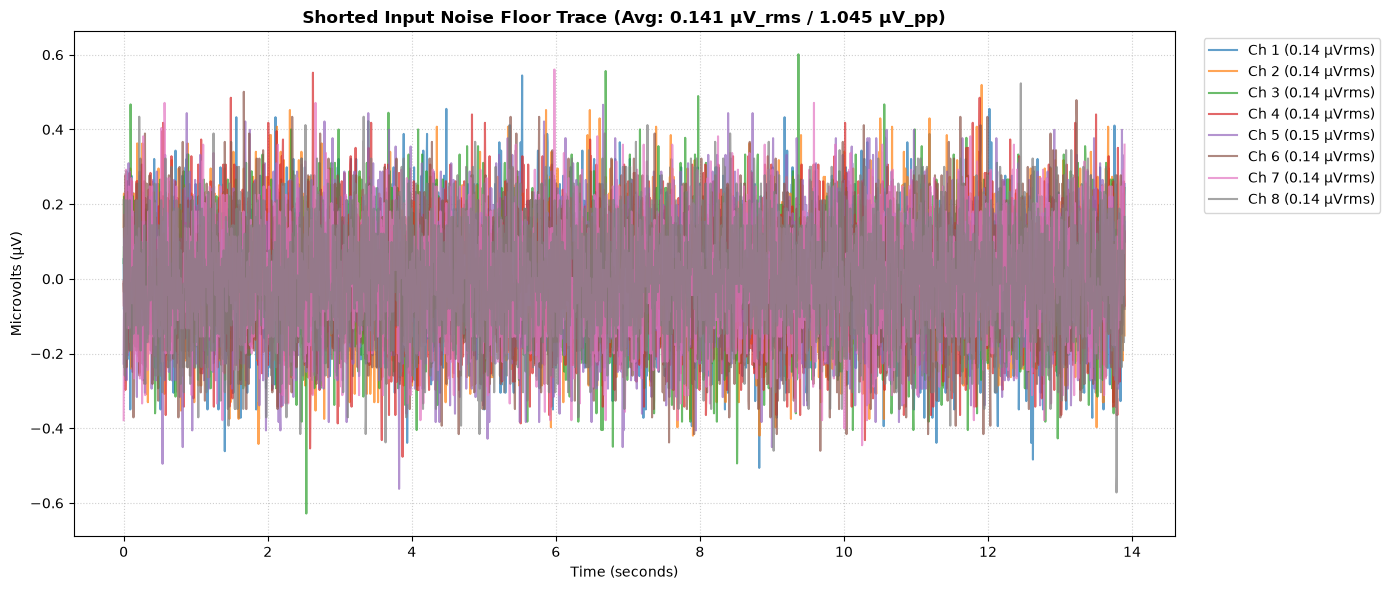

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA FILES
# ==========================================
# File 1: Shorted Inputs Recording
shorted_file = "recordings/shorted.npz"

# File 2: Test Signal Recording (Set to None if not recorded yet)
# e.g., "recordings/eeg_recording_testsignal.npz"
test_signal_file = "recordings/test_signal.npz"

data_shorted_raw = np.load(shorted_file)
key_shorted = list(data_shorted_raw.keys())[0]
raw_shorted = data_shorted_raw[key_shorted]  # Shape: (Samples, Channels)

FS = 250.0  # 250 SPS
GAIN = 24.0

# Ensure data is zero-mean per channel to remove residual DC offset
raw_shorted_demeaned = raw_shorted - np.mean(raw_shorted, axis=0)

# ==========================================
# 2. NOISE FLOOR METRICS (Shorted Inputs)
# ==========================================
# RMS Noise (Standard Deviation)
v_rms = np.std(raw_shorted_demeaned, axis=0)

# Peak-to-Peak Noise (V_pp)
v_pp = np.ptp(raw_shorted_demeaned, axis=0)

print("=" * 60)
print(
    f"ADS1299 INPUT-REFERRED NOISE FLOOR (Gain = {int(GAIN)}, SPS = {int(FS)})")
print("=" * 60)
for ch in range(raw_shorted.shape[1]):
    print(
        f"Ch {ch + 1}: RMS Noise = {v_rms[ch]:6.3f} uV_rms  |  V_pp = {v_pp[ch]:6.3f} uV_pp")

avg_rms = np.mean(v_rms)
avg_pp = np.mean(v_pp)
print("-" * 60)
print(f"AVERAGE NOISE FLOOR : {avg_rms:.3f} uV_rms  |  {avg_pp:.3f} uV_pp")
print(f"ADS1299 Datasheet Target (0.1-70Hz BW): ~0.14 uV_rms (~1.0 uV_pp)")
print("=" * 60)


# ==========================================
# 3. TEST SIGNAL ANALYSIS & SNR (If File Provided)
# ==========================================
if test_signal_file is not None:
    data_test_raw = np.load(test_signal_file)
    key_test = list(data_test_raw.keys())[0]
    raw_test = data_test_raw[key_test]

    # Demean test signal
    raw_test_demeaned = raw_test - np.mean(raw_test, axis=0)

    # Signal RMS Power (Total Power minus Noise Power)
    signal_rms = np.std(raw_test_demeaned, axis=0)

    # Calculate SNR in Decibels: SNR_dB = 20 * log10(V_signal_rms / V_noise_rms)
    snr_db = 20 * np.log10(signal_rms / v_rms)

    print("\n" + "=" * 60)
    print("TEST SIGNAL EVALUATION & SNR")
    print("=" * 60)
    for ch in range(raw_test.shape[1]):
        print(
            f"Ch {ch + 1}: Signal RMS = {signal_rms[ch]:8.2f} uV_rms  |  SNR = {snr_db[ch]:6.2f} dB")

    print("-" * 60)
    print(f"AVERAGE SNR: {np.mean(snr_db):.2f} dB")
    print("=" * 60)


# ==========================================
# 4. VISUALIZATION (Time Domain Traces)
# ==========================================
time_axis = np.arange(raw_shorted.shape[0]) / FS

plt.figure(figsize=(14, 6), dpi=100)
for ch in range(raw_shorted.shape[1]):
    plt.plot(time_axis, raw_shorted_demeaned[:, ch],
             label=f"Ch {ch + 1} ({v_rms[ch]:.2f} µVrms)", alpha=0.7)

plt.title(
    f"Shorted Input Noise Floor Trace (Avg: {avg_rms:.3f} µV_rms / {avg_pp:.3f} µV_pp)", fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Microvolts (µV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()